# 게이트가 추가된 RNN

5장에서 본 RNN은 순환 경로를 포함하며 과거의 정보를 기억할 수 있었음   
구조가 단순하여 구현도 쉽게 할 수 있었음   
하지만 성능이 좋지 못함   
그 원인은 (많은 경우) 시계열 데이터에서 시간적으로 멀리 떨어진, 장기(long term) 의존 관계를 잘 학습할 수 없다는 데 있음   

요즘에는 앞 장의 단순한 RNN 대신 LSTM이나 GRU라는 계층이 주로 쓰임   
실제로 그냥 'RNN'이라고 하면 앞 장의 RNN이 아니라 LSTM을 가리키는 경우도 흔함   
오히려 앞 장의 RNN을 명시적으로 가리킬 때 '기본(적인) RNN'이라 하기도 함   

LSTM이나 GRU에는 '게이트(gate)'라는 구조가 더해져 있는데, 이 게이트 덕분에 시계열 데이터의 장기 의존 관계를 학습할 수 있음   
이번 장에서는 앞 장의 기본 RNN의 문제점을 알아보고, 이를 대신하는 계층으로써 LSTM과 GRU와 같은 '게이트가 추가된 RNN'을 살펴봄   
특히 LSTM의 구조를 시간을 들여 차분히 살펴보고, 이 구조가 '장기 기억'을 가능하게 하는 메커니즘을 이해해봄   
그리고 LSTM을 사용해 언어 모델을 만들어, 실제로 데이터를 잘 학습하는 모습도 살펴봄

## RNN의 문제점

앞 장의 RNN은 시계열 데이터의 장기 의존 관계를 학습하기 어려움   
그 원인은 BPTT에서 기울기 소실 혹은 기울기 폭발이 일어나기 때문   
이번 절에서는 앞 장의 RNN 계층을 복습하고, 뒤이어 RNN 계층이 장기 기억을 제대로 처리하지 못하는 이유를 사례를 들어 설명할 것

### RNN 복습

RNN 계층은 순환 경로를 갖고 있음   
그리고 그 순환을 펼치면 다음 그림과 같이 옆으로 길게 뻗은 신경망이 만들어짐   
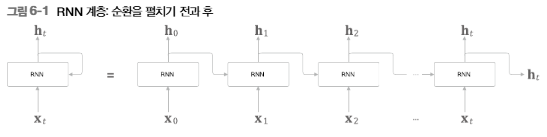   
- 그림에서 보듯, RNN 계층은 시계열 데이터인 xt를 입력하면 ht를 출력함
- 이 ht는 RNN 계층의 은닉 상태라고 하여, 과거 정보를 저장함   

RNN의 특징은 이전 시각의 은닉 상태를 이용한다는 점   
이렇게 해서 과거 정보를 계승할 수 있게 됨   
이때 RNN 계층이 수행하는 처리를 계산 그래프로 나타내면   
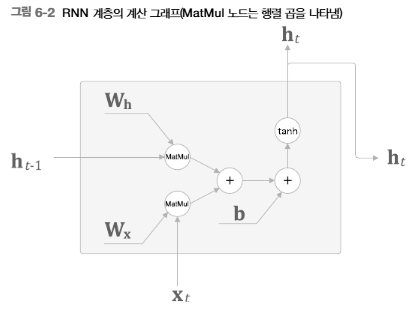   
- 그림처럼 RNN 계층의 순전파에서 수행하는 계산은 행렬의 곱과 합, 그리고 활성화 함수인 tanh 함수에 의한 변환으로 구성됨   

여기까지가 앞 장에서 본 RNN 계층   
이어서 이 RNN 계층이 안고 있는 문제, 즉 장기 기억에 취약하다는 문제를 살펴봄

### 기울기 소실 또는 기울기 폭발

언어 모델은 주어진 단어들을 기초로 다음에 출현할 단어를 예측하는 일을 함   
앞 장에서는 RNN을 사용해 언어 모델을 구현했음(RNNLM이라 불렀음)   
이번 절에서는 RNNLM의 단점을 확인하는 차원에서 아래 그림의 문제를 다시 한번 생각해봄   
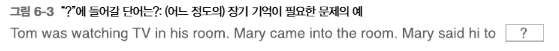   
- 앞에서도 나왔듯이 '?'에 들어가는 단어는 'Tom'
- RNNLM이 이 문제에 올바르게 답하려면, 현재 맥락에서 "Tom이 방에서 TV를 보고 있음"과 "그 방에 Mary가 들어옴"이란 정보를 기억해둬야 함
- 다시 말해 이런 정보를 RNN 계층의 은닉 상태에 인코딩해 보관해둬야 함   

그럼 이 예를 RNNLM 학습의 관점에서 생각해보면   
여기에서는 정답 레이블로 'Tom'이라는 단어가 주어졌을 때, RNNLM에서 기울기가 어떻게 전파되는지를 살펴볼 것   
물론, 학습은 BPTT로 수행함   
따라서 정답 레이블이 'Tom'이라고 주어진 시점으로부터 과거 방향으로 기울기를 전달하게 됨   
그림으로 보면   
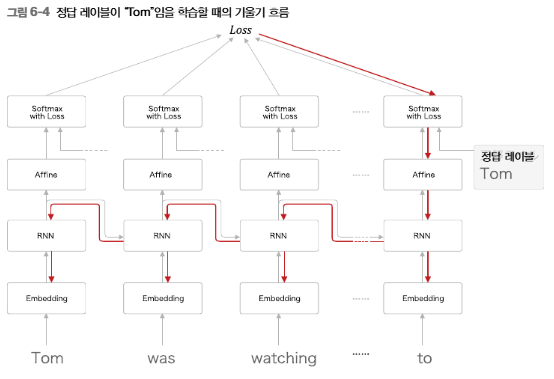   
- 그림에서와 같이 정답 레이블이 'Tom'임을 학습할 때 중요한 것이 바로 RNN 계층의 존재
- RNN 계층이 과거 방향으로 '의미 있는 기울기'를 전달함으로써 시간 방향의 의존 관계를 학습할 수 있는 것
- 이때 기울기는 (원래대로라면) 학습해야 할 의미가 있는 정보가 들어 있고, 그것을 과거로 전달함으로써 장기 의존 관계를 학습함
- 하지만 만약 이 기울기가 중간에 사그라들면 (거의 아무런 정보도 남지 않게 되면) 가중치 매개변수는 전혀 갱신되지 않게 됨
- 즉, 장기 의존 관계를 학습할 수 없게 됨
- 안타깝지만, 현재의 단순한 RNN 계층에서는 시간을 거슬러 올라갈수록 기울기가 작아지거나(기울기 소실) 혹은 커질 수 있으며(기울기 폭발), 대부분 둘 중 하나의 운명을 걷게 됨

### 기울기 소실과 기울기 폭발의 원인

그럼 RNN 계층에서 기울기 소실(혹은 기울기 폭발)이 일어나는 원인을 살펴보기   
아래 그림과 같이 RNN 계층에서의 시간 방향 기울기 전파에만 주목해보면   
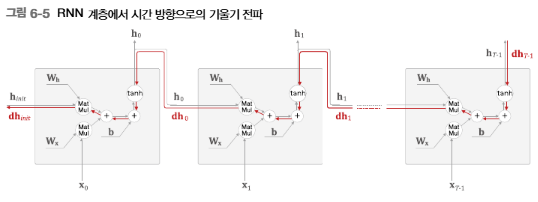   
- 그림처럼 길이가 T인 시계열 데이터를 가정하여 T번째 정답 레이블로부터 전해지는 기울기가 어떻게 변하는지 확인
- 앞의 문제에 대입하면 T번째 정답 레이블이 'Tom'인 경우에 해당함
- 이때 시간 방향 기울기에 주목하면 역전파로 전해지는 기울기는 차례로 'tanh', '+', 'MatMul(행렬 곱)' 연산을 통과한다는 것을 알 수 있음
- '+'의 역전파는 상류에서 전해지는 기울기를 그대로 하류로 흘려보낼 뿐 - 그래서 기울기는 변하지 않음


나머지 두개 중 'tanh'를 먼저 살펴보면   

---
### 부록 Tanh 함수의 미분

함수는 쌍곡탄젠트 혹은 하이퍼볼릭 탄젠트(hyperbolic tangent)라고도 함   
tanh 함수의 식은   
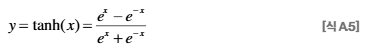   
- 위 식에서 을 구하는 것이 목표
- 여기에서는 다음 미분 공식을 이용함   

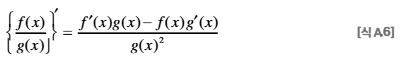   
- 이 식은 분수 함수의 미분 공식
- 이번 절에서는 보기 편하도록 의 x에 대한 미분을 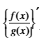로 표기하고,
- 마찬가지로 f(x)의 x에 대한 미분은  f'(x)로 표기
- 또한 네이피어 수(e)에 대해서는 다음처럼 미분을 해석적으로 유도할 수 있음   

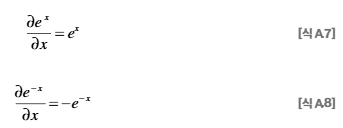   
- 위 식 3가지를 이용하면 tanh 함수의 미분을 다음과 같이 구할 수 있음   

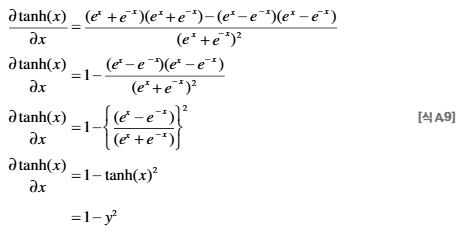   
- 위 식과 같이, tanh 함수의 미분은 '분수 함수의 미분 공식'을 사용하여 간단한 식으로 변형해 구할 수 있음
- 변형된 결과는 

이 결과로부터, tanh 함수의 계산 그래프는   
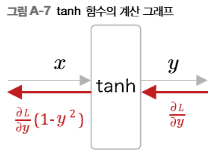   

---

y = tanh(x)일 때의 미분은 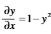   
이때 y = tanh(x)의 값과 그 미분 값을 각각 그래프로 그리면   
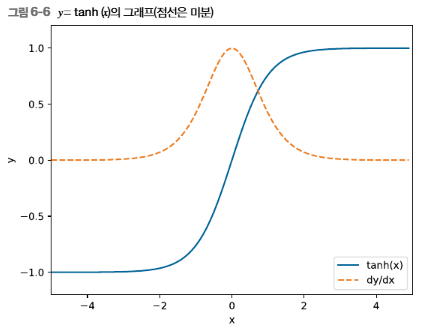   
- 그림에서 점선이 y = tanh(x)의 미분
- 보다시피 그 값은 1.0 이하이고, x가 0으로부터 멀어질수록 작아짐
- 달리 말하면, 역전파에서는 기울기가 tanh 노드를 지날 때마다 값은 계속 작아진다는 뜻
- 그래서 tanh 함수를 T번 통과하면 기울기도 T번 반복해서 작아지게 됨   

> RNN 계층의 활성화 함수로는 주로 tanh 함수를 사용하는데, 이를 ReLU로 바꾸면 기울기 소실을 줄일 수 있음(ReLU에 x를 입력하면 max(0, x)를 출력함)   
> 그 이유는 ReLU는 입력 x가 0 이상이면, 역전파 시 상류의 기울기를 그대로 하류에 흘려보내기 때문   
> 즉, 기울기가 작아지지 않음   
> 실제로「Improving performance of recurrent neural network with relu nonlinearity」논문에서는 ReLU를 사용해 성능을 개선했음   

다음은 MatMul(행렬 곱)노드 차례   
여기에서는 이야기를 단순하게 하기 위해 위에 그림의 tanh 노드를 무시하기로 함   
그러면 RNN 계층의 역전파 시 기울기는 아래 그림과 같이 'MatMul' 연산에 의해서만 변화하게 됨   
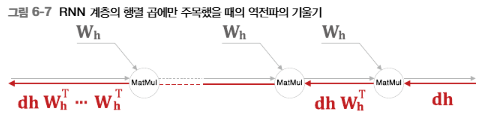   
- 그림은 상류로부터 dh라는 기울기가 흘러온다고 가정함
- 이때 MatMul 노드에서의 역전파는 라는 행렬 곱으로 기울기를 계산함
- 그리고 같은 계산을 시계열 데이터의 시간 크기만큼 반복
- 여기에서 주목할 점은 이 행렬 곱셈에서는 매번 똑같은 가중치인 Wh가 사용된다는 것   

그러면 역전파 시 기울기는 MatMul 노드를 지날 때마다 어떻게 변하는지?   
코드를 통해 기울기의 크기 변화를 관찰해보면

[np.float64(2.4684068094579303), np.float64(3.335704974161037), np.float64(4.783279375373183), np.float64(6.2795873320876145), np.float64(8.080776465019055), np.float64(10.25116303229294), np.float64(12.9360635066099), np.float64(16.276861327786712), np.float64(20.454829618345983), np.float64(25.688972842084684), np.float64(32.25315718048336), np.float64(40.48895641683869), np.float64(50.824407307019094), np.float64(63.79612654485427), np.float64(80.07737014308985), np.float64(100.51298922051251), np.float64(126.16331847536827), np.float64(158.3592064825883), np.float64(198.77107967611957), np.float64(249.495615421267)]


c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45432 (\N{HANGUL SYL

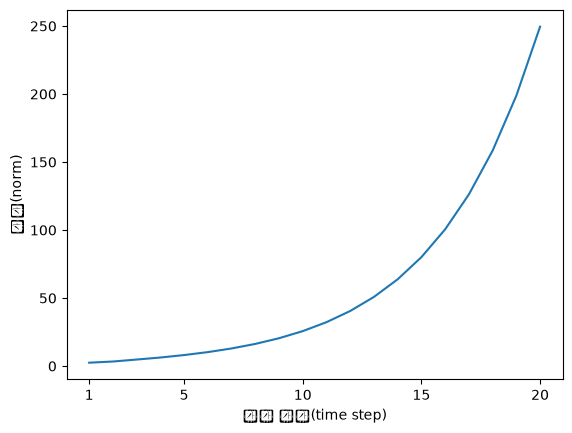

In [1]:
import numpy as np
import matplotlib.pyplot as plt


N = 2   # 미니배치 크기
H = 3   # 은닉 상태 벡터의 차원 수
T = 20  # 시계열 데이터의 길이

dh = np.ones((N, H))

np.random.seed(3) # 재현할 수 있도록 난수의 시드 고정

Wh = np.random.randn(H, H)

norm_list = []
for t in range(T):
    dh = np.dot(dh, Wh.T)
    norm = np.sqrt(np.sum(dh**2)) / N
    norm_list.append(norm)

print(norm_list)

# 그래프 그리기
plt.plot(np.arange(len(norm_list)), norm_list)
plt.xticks([0, 4, 9, 14, 19], [1, 5, 10, 15, 20])
plt.xlabel('시간 크기(time step)')
plt.ylabel('노름(norm)')
plt.show()

- 이 코드에서는 dh를 np.ones()로 초기화 (np.ones()는 모든 원소가 1인 행렬을 반환)
- 그리고 역전파의 MatMul 노드 수(T)만큼 dh를 갱신하고, 각 단계에서 dh 크기(노름)를 norm_list에 추가
- 또한 여기에서는 미니배치(N개)의 평균 'L2 노름'을 구해 dh 크기로 사용하고 있음
- 참고로, L2 노름이란 각각의 원소를 제곱해 모두 더하고 제곱근을 취한 값   

이 코드를 실행한 결과(norm_list) 그래프를 보면   
- 기울기의 크기는 시간에 비례해 지수적으로 증가 - 이것이 기울기 폭발(exploding gradients)
- 이러한 기울기 폭발이 일어나면 결국 오버플로를 일으켜 NaN(Not a Number) 같은 값을 발생시킴
- 따라서 신경망 학습을 제대로 수행할 수 없게 됨   

그러면 Wh의 초깃값을 변경하여 다시 실험

[np.float64(1.2342034047289652), np.float64(0.8339262435402592), np.float64(0.5979099219216478), np.float64(0.3924742082554759), np.float64(0.25252426453184545), np.float64(0.16017442237957719), np.float64(0.10106299614538984), np.float64(0.06358148956166684), np.float64(0.039950839098332), np.float64(0.025086887541098325), np.float64(0.015748611904532892), np.float64(0.009884999125204758), np.float64(0.006204151282595104), np.float64(0.003893806551809953), np.float64(0.002443767399386287), np.float64(0.0015337065005571367), np.float64(0.0009625497320203268), np.float64(0.0006040924319556743), np.float64(0.00037912574706291117), np.float64(0.00023793756048323344)]


c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45432 (\N{HANGUL SYL

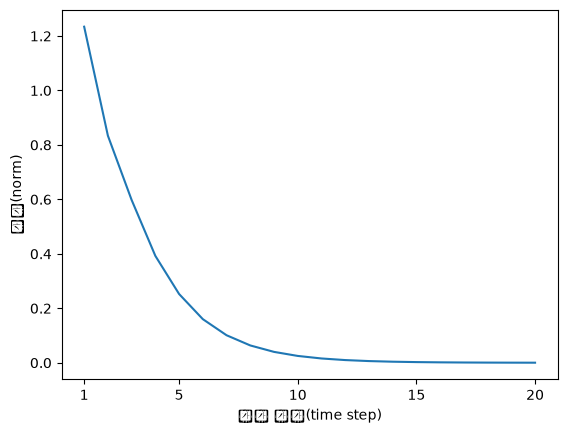

In [2]:
dh = np.ones((N, H))

np.random.seed(3)

Wh = np.random.randn(H, H) * 0.5

norm_list = []
for t in range(T):
    dh = np.dot(dh, Wh.T)
    norm = np.sqrt(np.sum(dh**2)) / N
    norm_list.append(norm)

print(norm_list)

# 그래프 그리기
plt.plot(np.arange(len(norm_list)), norm_list)
plt.xticks([0, 4, 9, 14, 19], [1, 5, 10, 15, 20])
plt.xlabel('시간 크기(time step)')
plt.ylabel('노름(norm)')
plt.show()

결과 그래프를 보면   
- 이번에는 기울기가 지수적으로 감소 - 이것이 기울기 소실(vanishing gradients)
- 기울기 소실이 일어나면 기울기가 매우 빠르게 작아짐
- 그리고 기울기가 일정 수준 이하로 작아지면 가중치 매개변수가 더 이상 갱신되지 않으므로, 장기 의존 관계를 학습할 수 없게 됨   

지금까지의 실험에서 기울기의 크기는 지수적으로 증가하거나 감소했음   
이런 지수적인 변화가 일어난 이유는 물론 행렬 Wh를 T번 반복해서 '곱'했기 때문   
만약 Wh가 스칼라라면 이야기는 단순해지는데, Wh가 1보다 크면 지수적으로 증가하고, 1보다 작으면 지수적으로 감소함   

그럼 Wh가 스칼라가 아니라 행렬이라면   
이 경우, 행렬의 '특잇값'이 척도가 됨   
행렬의 특잇값이란, 간단히 말하면 데이터가 얼마나 퍼져 있는지를 나타냄   
이 특잇값의 값(더 정확하게는 여러 특잇값 중 최댓값)이 1보다 큰지 여부를 보면 기울기 크기가 어떻게 변할지 예측할 수 있음   

> 특잇값의 최댓값이 1보다 크면 지수적으로 증가하고, 1보다 작으면 지수적으로 감소할 가능성이 높다고 예측할 수 있음   
> 그럴 가능성이 높을 뿐, 특잇값이 1보다 크다고 해서 기울기가 반드시 폭발하는 것은 아님   
> 즉, 필요조건일 뿐 충분조건은 아님

### 기울기 폭발 대책

지금까지 RNN의 문제점(기울기 폭발과 기울기 소실)을 살펴봤음   
그럼 계속해서, 그 해결책을 알아봄   

기울기 폭발부터 보면   
기울기 폭발의 대책으로는 전통적인 기법이 있음 - 기울기 클리핑(gradients clipping)이라는 기법   
기울기 클리핑은 매우 단순하며, 그 알고리즘을 의사 코드로 쓰면 다음과 같음   
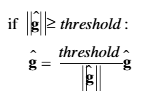   
- 여기에서는 신경망에서 사용되는 모든 매개변수에 대한 기울기를 하나로 처리한다고 가정하고, 이를 기호 으로 표기했음
- 그리고 threshold를 문턱값으로 설정
- 이때 기울기의 L2 노름(수식에서는 )이 문턱값을 초과하면 두 번째 줄의 수식과 같이 기울기를 수정함   

이것이 기울기 클리핑   
보다시피 단순한 알고리즘이지만, 많은 경우에 잘 작동함   

> 은 신경망에서 사용되는 모든 매개변수의 기울기를 하나로 모은 것   
> 예컨대 두 개의 가중치 W1과 W2 매개변수를 사용하는 모델이 있다면, 이 두 매개변수에 대한 기울기 dW1과 dW2를 결합한 것을 이라 하는 것

이제 기울기 클리핑을 파이썬으로 구현해볼 차례   
기울기 클리핑은 clip_grads(grads, max_norm)이라는 함수로 구현   
인수 grads는 기울기의 리스트, max_norm은 문턱값을 뜻함   
이때 기울기 크리핑은 다음과 같이 구현할 수 있음

In [3]:
import numpy as np


dW1 = np.random.rand(3, 3) * 10
dW2 = np.random.rand(3, 3) * 10
grads = [dW1, dW2]
max_norm = 5.0


def clip_grads(grads, max_norm):
    total_norm = 0
    for grad in grads:
        total_norm += np.sum(grad ** 2)
    total_norm = np.sqrt(total_norm)

    rate = max_norm / (total_norm + 1e-6)
    if rate < 1:
        for grad in grads:
            grad *= rate


print('before:', dW1.flatten())
clip_grads(grads, max_norm)
print('after:', dW1.flatten())

before: [6.49144048 2.78487283 6.76254902 5.90862817 0.23981882 5.58854088
 2.59252447 4.15101197 2.83525082]
after: [1.49503731 0.64138134 1.55747605 1.36081038 0.05523244 1.28709139
 0.59708178 0.95601551 0.65298384]


구현에 특별히 어려운 점은 없음   
이 함수는 앞으로도 이용할 예정   

> 이 책에서는 RNNLM을 학습시키는 RnnlmTrainer 클래스(common/trainer.py)를 제공함   
> 이 클래스 내부에서도 이 기울기 클리핑 함수를 이용해 기울기 폭발을 방지함   
> RnnlmTrainer 클래스에서의 기울기 클리핑에 대해서는 '6.4 LSTM을 사용한 언어 모델' 절에서 다시 설명

## 기울기 소실과 LSTM

RNN 학습에서는 기울기 소실도 큰 문제   
그리고 이 문제를 해결하려면 RNN 계층의 아키텍처를 근본부터 뜯어고쳐야 함   
여기서 등장하는 것이 이번 장의 핵심 주제인 '게이트가 추가된 RNN   
게이트가 추가된 RNN으로는 많은 아키텍처(신경망 구성)가 제안되어 있으며, 그 대표격으로 LSTM과 GRU가 있음   
이번 절에서는 LSTM에 집중하여 그 구조를 차분히 살펴보면서 LSTM이 기울기 소실을 일으키지 않는다는(혹은 일으키기 어렵게 한다는) 사실을 밝힐 예정   
참고로, GRU에 관해서는 '부록 C. GRU'에서 설명

### LSTM의 인터페이스

LSTM의 계층을 자세히 살펴보기 전에 잠시 앞으로를 위해 계산 그래프를 단순화하는 도법을 하나 도입함   
아래 그림과 같이 행렬 계산 등을 하나의 직사각형 노드로 정리해 그리는 방식   
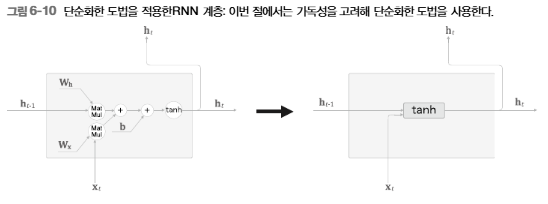   
- 그림에서 보듯, 여기에서는  계산을 tanh라는 직사각형 노드 하나로 그렸음(ht-1과 xt는 행벡터)
- 이 직사각형 노드 안에 행렬 곱과 편향의 합, 그리고 tanh 함수에 의한 변환이 모두 포함된 것   

사전 준비는 이것으로 끝   
이제 LSTM의 인터페이스(입출력)를 RNN과 비교하는 것부터 시작해보면   
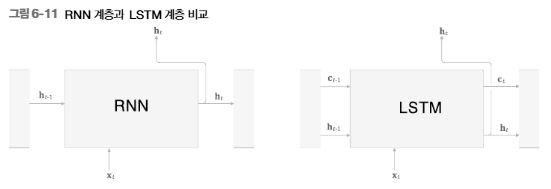   
- 그림에서 보듯 LSTM 계층의 인터페이스에는 c라는 경로가 있다는 차이가 있음
- 이 c를 **기억 셀(memory cell)(혹은 단순히 '셀')** 이라 하며, LSTM 전용의 기억 메커니즘
- 기억 셀의 특징은 데이터를 자기 자신으로만(LSTM 계층 내에서만) 주고받는다는 것
- 즉, LSTM 계층 내에서만 완결되고, 다른 계층으로는 출력하지 않음
- 반면, LSTM의 은닉 상태 h는 RNN 계층과 마찬가지로 다른 계층으로(위쪽으로) 출력됨   

> LSTM의 출력을 받는 쪽에서 보면 LSTM의 출력은 은닉 상태 벡터 h뿐   
> 기억 셀 c는 외부에서는 보이지 않음   
> 그래서 그 존재 자체를 생각할 필요가 없음

### LSTM 계층 조립하기

그럼 LSTM 계층의 내용을 살펴봄   
여기에서는 LSTM의 부품을 하나씩 조립하면서, 그 구조를 차분히 알아볼 것   
참고로, 이번 절은 LSTM을 훌륭히 설명한 블로그 글「Understanding LSTM Networks」를 참고한 내용   

앞서 이야기한 것처럼, LSTM에는 기억 셀 ct가 있음   
이 ct에는 시각 t에서의 LSTM의 기억이 저장돼 있는데, 과거로부터 시각 t까지에 필요한 모든 정보가 저장돼 있다고 가정함(혹은 그렇게 되도록 학습을 수행)   
그리고 필요한 정보를 모두 간직한 이 기억을 바탕으로, 외부 계층에(그리고 다음 시각의 LSTM에) 은닉 상태 ht를 출력함   
이때 출력하는 ht는 아래 그림과 같이 기억 셀의 값을 tanh 함수로 변환한 값   
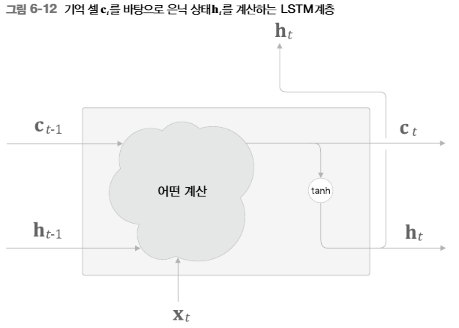   
- 그림처럼 현재의 기억 셀 ct는 3개의 입력(ct-1, ht-1, xt)으로부터 '어떤 계산'을 수행하여 구할 수 있음('어떤 계산'의 자세한 내용은 곧 설명)
- 여기서 핵심은 갱신된 ct를 사용해 은닉 상태 ht를 계산한다는 것
- 또한 이 계산은 ht = tanh(ct)인데, 이는 ct의 각 요소에 tanh 함수를 적용한다는 뜻   

> 기억 셀 ct와 은닉 상태 ht의 관계는 (여기까지의) ct의 각 원소에 tanh 함수를 적용한 것일 뿐   
> 이 말이 뜻하는 바는 기억 셀 ct와 은닉 상태 ht의 원소 수는 같다는 것   
> 예컨대 기억 셀 ct의 원소가 100개면 은닉 상태 ht의 원소 수도 100개가 됨   

먼저 '게이트'라는 기능에 대해 간단하게 설명   
게이트란 우리말로는 '문'을 의미하는 단어   
문은 열거나 닫을 수 있듯이, 게이트는 데이터의 흐름을 제어   
마치 아래 그림처럼 물의 흐름을 멈추거나 배출하는 것이 게이트의 역할   
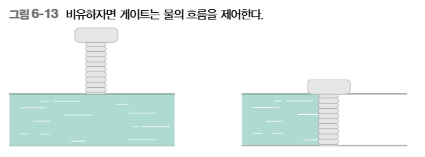   
- LSTM에서 사용하는 게이트는 '열기/닫기'뿐 아니라, 어느 정도 열지를 조절할 수 있음
- 다시 말해 다음 단계로 흘려보낼 물의 양을 제어
- '어느 정도'를 '열림 상태(openness)'라 부르며, 아래 그림처럼 0.7(70%)이나 0.2(20%)처럼 제어할 수 있음   

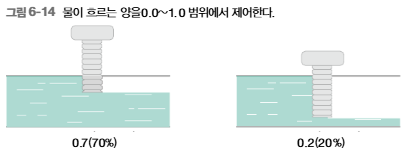   
- 그림처럼 게이트의 열림 상태는 0.0 ~ 1.0 사이의 실수로 나타남(1.0은 완전 개방)
- 그리고 그 값이 다음으로 흐르는 물의 양을 결정
- 여기서 중요한 것은 '게이트를 얼마나 열까'라는 것도 데이터로부터 (자동으로) 학습한다는 점   

> 게이트는 게이트의 열림 상태를 제어하기 위해서 전용 가중치 매개변수를 이용하며, 이 가중치 매개변수는 학습 데이터로부터 갱신됨   
> 참고로, 게이트의 열림 상태를 구할 때는 시그모이드 함수를 사용하는데, 시그모이드 함수의 출력이 마침 0.0 ~ 1.0 사이의 실수이기 때문

### output 게이트

다시 LSTM 이야기로 돌아오면   
바로 앞에서 은닉 상태 ht는 기억 셀 ct에 단순히 tanh 함수를 적용했을 뿐이라고 설명했음   
이번 절에서는 tanh(ct)에 게이트를 적용하는 걸 생각해봄   
즉, tanh(ct)의 각 원소에 대해 '그것이 다음 시각의 은닉 상태에 얼마나 중요한가'를 조정함   
한편, 이 게이트는 다음 은닉 상태 ht의 출력을 담당하는 게이트이므로 **output 게이트(출력 게이트)** 라고 함   

output 게이트의 열림 상태(다음 몇 %만 흘려보낼까)는 입력 xt와 이전 상태 ht-1로부터 구함   
이때의 계산은 아래 식과 같음   
참고로, 여기서 사용하는 가중치 매개변수와 편향에는 output의 첫 글자인 o를 첨자로 추가함   
이후에도 마찬가지로 첨자를 붙여 게이트임을 표시함   
한편, 시그모이드 함수는 로 표기함   
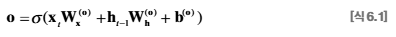   
- 식에서 보듯, 입력 xt에는 가중치 가, 이전 시각의 은닉 상태 ht-1에는 가중치 가 붙어있음(xt와 ht-1은 행벡터)
- 그리고 이 행렬들의 곱과 편향 b(o)를 모두 더한 다음 시그모이드 함수를 거쳐 출력 게이트의 출력 o를 구함
- 마지막으로 이 o와 tanh(ct)의 원소별 곱을 ht로 출력하는 것   

이상의 계산을 계산 그래프로는   
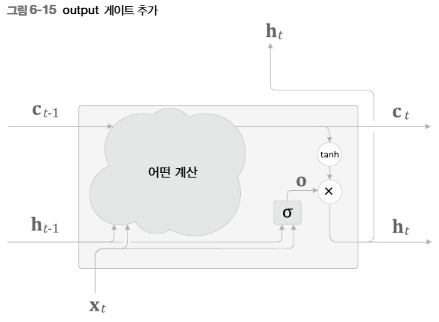   
- 그림과 같은 output 게이트에서 수행하는 위 식의 계산을 'σ'로 표기
- 그리고 σ의 출력을 o라고 하면 ht는 o와 tanh(ct)의 곱으로 계산됨
- 여기서 말하는 '곱'이란 원소별 곱이며, 이것을 **아다마르 곱(Hadamard product)** 이라고도 함
- 아다마르 곱을 기호로는 ⊙으로 나타내며, 아래 식과 같은 계산을 수행함   

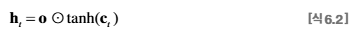   

여기까지가 LSTM의 output 게이트   
이제 LSTM의 출력 부분은 완성되었음   
이어서 기억 셀 갱신 부분을 살펴봄   

> tanh의 출력은 -1.0 ~ 1.0의 실수   
> 이 -1.0 ~ 1.0의 수치를 그 안에 인코딩된 '정보'의 강약(정도)을 표시한다고 해석할 수 있음   
> 한편 시그모이드 함수의 출력은 0.0 ~ 1.0의 실수이며, 데이터를 얼마만큼 통과시킬지를 정하는 비율을 뜻함   
> 따라서 (주로) 게이트에서는 시그모이드 함수가, 실질적인 '정보'를 지니는 데이터에는 tanh 함수가 활성화 함수로 사용됨

### forget 게이트

다음에 해야 할 일은 기억 셀에 '무엇을 잊을까'를 명확하게 지시하는 것   
이런 일도 물론 게이트를 사용해 해결함   

그러면 ct-1의 기억 중에서 불필요한 기억을 잊게 해주는 게이트를 추가해봄   
이를 **forget 게이트(망각 게이트)** 라 부르도록 함   
forget 게이트를 LSTM 계층에 추가한 계산 그래프는   
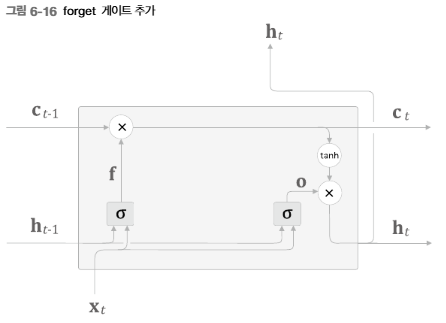   
- 그림에서는 forget 게이트가 수행하는 일련의 계산을 σ 노드로 표기했음
- 이 σ 안에는 forget 게이트 전용의 가중치 매개변수가 있으며, 다음 식의 계산을 수행함   

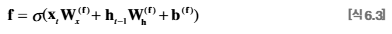   
- 식을 실행하면 forget 게이트의 출력 f가 구해짐
- 그리고 이 f와 이전 기억 셀인 ct-1과의 원소별 곱, 즉 을 계산하여 ct를 구함

### 새로운 기억 셀

forget 게이트를 거치면서 이전 시각의 기억 셀로부터 잊어야 할 기억이 삭제되었음   
그런데 이 상태로는 기억 셀이 잊는 것밖에 하지 못함   
그래서 새로 기억해야 할 정보를 기억 셀에 추가해야 함   
그러기 위해서 아래 그림과 같이 tanh 노드를 추가   
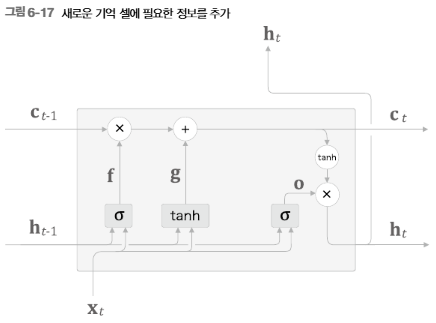   
- 그림에서 보듯 tanh 노드가 계산한 결과가 이전 시각의 기억 셀 ct-1에 더해짐
- 기억 셀에 새로운 '정보'가 추가된 것
- 이 tanh 노드는 '게이트'가 아니며, 새로운 '정보'를 기억 셀에 추가하는 것이 목적
- 따라서 활성화 함수로는 시그모이드 함수가 아닌 tanh 함수가 사용됨
- 이 tanh 노드에서 수행하는 계산은 다음과 같음   

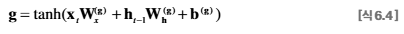   
- 여기에서는 기억 셀에 추가하는 새로운 기억을 g로 표기했음
- 이 g가 이전 시각의 기억 셀인 ct-1에 더해짐으로써 새로운 기억이 생겨남

### input 게이트

마지막으로 위 그림의 g에 게이트를 하나 추가   
여기에서 새롭게 추가하는 게이트를 input 게이트(입력 게이트)라고 함   
input 게이트를 추가한 계산 그래프는   
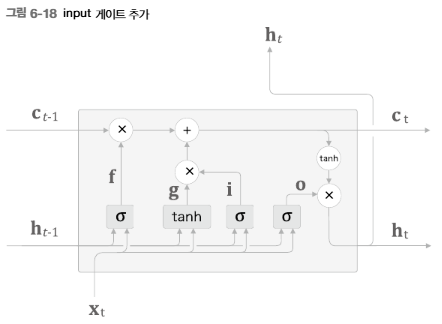   
- input 게이트는 g의 각 원소가 새로 추가되는 정보로써의 가치가 얼마나 큰지를 판단
- 새 정보를 무비판적으로 수용하는 게 아니라, 적절히 취사선택하는 것이 이 게이트의 역할
- 다른 관점에서 보면, input 게이트에 의해 가중된 정보가 새로 추가되는 셈
- 그림에서는 input 게이트를 σ로, 그 출력을 i로 표기했음
- 이때 수행하는 계산은 다음과 같음   

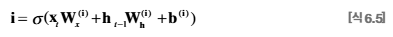   
- 그런 다음 i와 g의 원소별 곱 결과를 기억 셀에 추가함   

이상이 LSTM 안에서 이뤄지는 처리   

> LSTM에는 '변종'이 몇 가지 있음   
> 지금까지 설명한 LSTM이 대표적인 LSTM이지만, 이 외에도 게이트 연결 방법이 (약간) 다른 계층도 볼 수 있음

### LSTM의 기울기 흐름

LSTM의 구조는 설명했지만, 이것이 어떤 원리로 기울기 소실을 없애주는 것인지   
그 원리는 기억 셀 c의 역전파에 주목하면 보임   
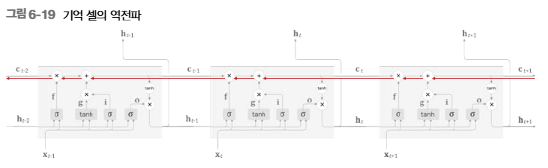   
- 그림은 기억 셀에만 집중하여, 그 역전파의 흐름을 그린 것
- 이때 기억 셀의 역전파에서는 '+'와 '×' 노드만을 지나게 됨
- '+' 노드는 상류에서 전해지는 기울기를 그대로 흘릴 뿐
    - 따라서 기울기 변화(감소)는 일어나지 않음
- 남는 것은 '×' 노드인데, 이 노드는 '행렬 곱'이 아닌 '원소별 곱(아마다르 곱)'을 계산함
- 참고로, 앞에서 본 RNN의 역전파에서는 똑같은 가중치 행렬을 사용하여 '행렬 곱'을 반복했고, 그래서 기울기 소실(또는 기울기 폭발)이 일어났음
- 반면, 이번 LSTM의 역전파에서는 '행렬 곱'이 아닌 '원소별 곱'이 이뤄지고, 매 시각 다른 게이트 값을 이용해 원소별 곱을 계산함
- 이처럼 매번 새로운 게이트 값을 이용하므로 곱셈의 효과가 누적되지 않아 기울기 소실이 일어나지 않는 (혹은 일어나기 어려운) 것   

그림의 '×' 노드의 계산은 forget 게이트가 제어함(그리고 매 시각 다른 게이트 값을 출력함)   
- 그리고 forget 게이트가 '잊어야 한다'고 판단한 기억 셀의 원소에 대해서는 그 기울기가 작아지는 것
- 한편, forget 게이트가 '잊어서는 안 된다'고 판단한 원소에 대해서는 그 기울기가 약화되지 않은 채로 과거 방향으로 전해짐
- 따라서 기억 셀의 기울기가 (오래 기억해야 할 정보일 경우) 소실 없이 전파되리라 기대할 수 있음   

이상의 논의에서 LSTM의 기억 셀에서는 기울기 소실이 일어나지 않는(혹은 일어나기 어려운) 이유를 알 수 있었음   
따라서 기억 셀이 장기 의존 관계를 유지(학습)하리라 기대할 수 있음   

> LSTM은 Long Short-Term Memory를 줄인 이름   
> 이 용어는 **단기 기억(short-term memory)** 을 **긴(long)** 시간 지속할 수 있음을 의미

## LSTM 구현

우선 최초의 한 단계만 처리하는 LSTM 클래스를 구현한 다음, 이어서 T개의 단계를 한꺼번에 처리하는 Time LSTM 클래스를 구현할 예정   
다음 식은 LSTM에서 수행하는 계산을 정리한 수식들   
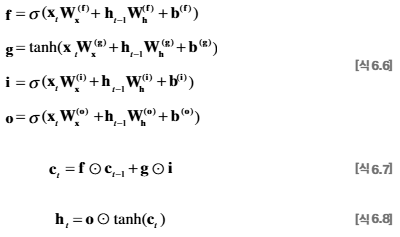   
- 이 식들이 LSTM에서 수행하는 계산
- 여기서 주목할 부분은 식 6.6의 네 수식에 포함된 아핀 변환(affine transformation)
- 여기에서의 '아핀 변환'이란 행렬 변환과 평행 이동(편향)을 결합한 형태, 즉  형태의 식을 가리킴
- 식 6.6의 네 수식에서는 아핀 변환을 개별적으로 수행하지만, 이를 하나의 식으로 정리해 계산할 수 있음
- 그 방법을 시각적으로 설명한 것이 아래 그림   

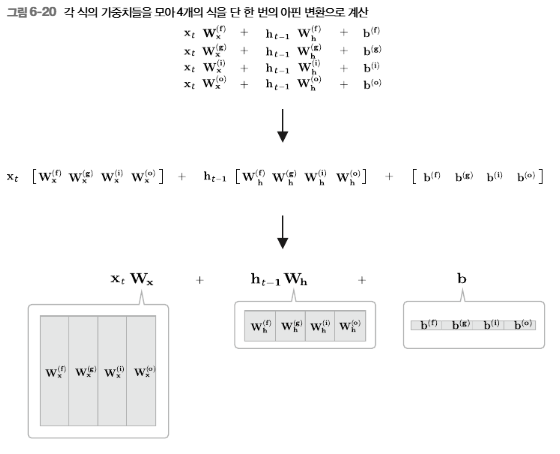   
- 그림에서 보듯 4개의 가중치(또는 편향)를 하나로 모을 수 있고, 그렇게 하면 원래 개별적으로 총 4번을 수행하던 아핀 변환을 단 1회의 계산으로 끝마칠 수 있음
- 계산 속도가 빨라진다는 뜻
- 왜냐하면 일반적으로 행렬 라이브러리는 '큰 행렬'을 한꺼번에 계산할 때가 각각을 따로 계산할 때보다 빠르기 때문
- 한편, 가중치를 한 데로 모아 관리하게 되어 소스 코드도 간결해짐   

그러면 Wx, Wh, b 각각에 4개분의 가중치(혹은 편향)가 포함되어 있다고 가정하고, 이때의 LSTM을 계산 그래프로 그려보면   
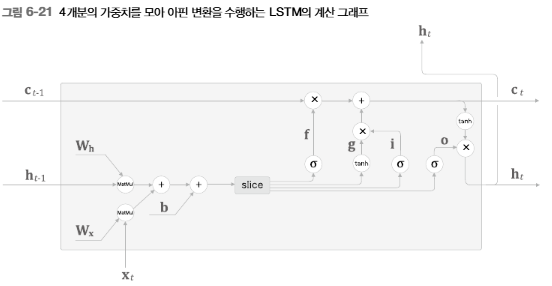   
- 그림에서 보듯 여기에서는 처음 4개분의 아핀 변환을 한꺼번에 수행
- 그리고 slice 노드를 통해 그 4개의 결과를 꺼냄
- slice는 아핀 변환의 결과(행렬)를 균등하게 네 조각으로 나눠서 꺼내주는 단순한 노드
- slice 노드 다음에는 활성화 함수(시그모이드 함수 또는 tanh 함수)를 거쳐 앞 절에서 설명한 계산을 수행함   

그럼 위 그림을 참고하여 LSTM 클래스를 구현하면(우선 LSTM 클래스의 초기화 코드)

In [6]:
import sys
sys.path.append('..')

import numpy as np # (or import cupy as np)
from common.layers import *
from common.functions import sigmoid

class LSTM:
    def __init__(self, Wx, Wh, b):
        '''
        Parameters
        ----------
        Wx: 입력 x에 대한 가중치 매개변수(4개분의 가중치가 담겨 있음)
        Wh: 은닉 상태 h에 대한 가장추 매개변수(4개분의 가중치가 담겨 있음)
        b: 편향(4개분의 편향이 담겨 있음)
        '''
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None

- 초기화 인수는 가중치 매개변수인 Wx와 Wh, 그리고 편향을 뜻하는 b
- 앞에서도 말한 것처럼 이 가중치(와 편향)에는 4개분의 가중치가 담겨 있음
- 이 인수들을 인스턴스 변수인 params에 할당하고, 이에 대응하는 형태로 기울기도 초기화
- 한편, cache는 순전파 때 중간 결과를 보관했다가 역전파 계산에 사용하려는 용도의 인스턴스 변수   

그럼 계속해서 순전파 구현   
순전파는 forward(x, h_prev, c_prev) 메서드로 구현함   
인수로는 현 시각의 입력 x, 이전 시각의 은닉 상태 h_prev, 이전 시각의 기억 셀 c_prev를 받음

In [8]:
def forward(self, x, h_prev, c_prev):
    Wx, Wh, b = self.params
    N, H = h_prev.shape

    A = np.dot(x, Wx) + np.dot(h_prev, Wh) + b

    # slice
    f = A[:, :H]
    g = A[:, H:2*H]
    i = A[:, 2*H:3*H]
    o = A[:, 3*H:]

    f = sigmoid(f)
    g = np.tanh(g)
    i = sigmoid(i)
    o = sigmoid(o)

    c_next = f * c_prev + g * i
    h_next = o * np.tanh(c_next)

    self.cache = (x, h_prev, c_prev, i, f, g, o, c_next)
    return h_next, c_next

- 이 메서드에서는 가장 먼저 아핀 변환을 함
- 이때 인스턴스 변수 Wx, Wh, b에는 각각 4개분의 매개변수가 저장되어 있으며, 이 변환을 행렬의 형상과 함께 그려보면   

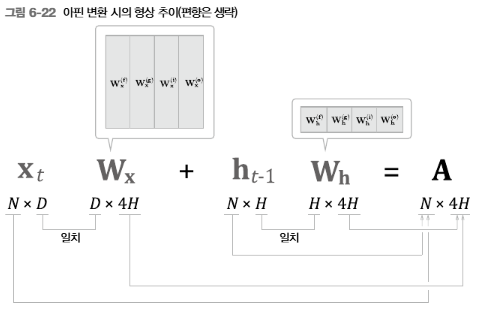   
- 그림에서는 미니배치 수를 N, 입력 데이터의 차원 수를 D, 기억 셀과 은닉 상태의 차원 수를 모두 H로 표시했음
- 그리고 계산 결과인 A에는 네 개분의 아핀 변환 결과가 저장됨
- 따라서 이 결과로부터 데이터를 꺼낼 때는 A[:, :H]나 A[:, H:2*H] 형태로 슬라이스해서 꺼내고, 꺼낸 데이터를 다음 연산 노드에 분배함
- 나머지 구현에 대해서는 LSTM의 수식과 계산 그래프를 참고하면 특별히 어려운 부분은 없음   

> LSTM 계층은 4개분의 가중치를 하나로 모아서 보관함   
> 그 덕분에 LSTM 계층은 매개변수를 총 3개만 관리하면 됨(Wx, Wh, b)   
> 참고로 RNN 계층도 똑같이 Wx, Wh, b라는 3개의 매개변수만 사용했음   
> 따라서 LSTM 계층과 RNN 계층의 매개변수 수는 같지만, 그 형상이 다른 것   

LSTM의 역전파는 위 그림의 계산 그래프를 역방향으로 전파해 구할 수 있음   
지금까지 익힌 지식을 활용하면 어렵지 않을 것   
다만, slice 노드는 이번에 처음 등장했으니 그 역전파에 대해 간단히 설명하면   
이 slice 노드는 행렬을 네 조각으로 나눠서 분배했음   
따라서 그 역전파에서는 반대로 4개의 기울기를 결합해야 함   
그림으로 보면   
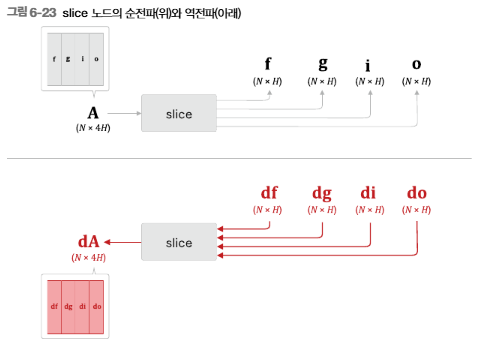   
- slice 노드의 역전파에서는 4개의 행렬을 연결함
- 그림에서는 4개의 기울기 df, dg, di, do를 연결해서 dA를 만들었음
- 이를 넘파이로 수행하려면 np.hstack() 메서드를 사용하면 됨
- np.hstack()은 인수로 주어진 배열들을 가로로 연결함(세로로 연결하는 np.vstack()도 있음)
- 따라서 이 처리를 다음의 단 한 줄로 끝낼 수 있음   
    - dA = np.hstack((df, dg, di, do))   

이상으로 slice 노드의 역전파를 알아봤음

In [9]:
class LSTM:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None

    def forward(self, x, h_prev, c_prev):
        Wx, Wh, b = self.params
        N, H = h_prev.shape

        A = np.dot(x, Wx) + np.dot(h_prev, Wh) + b

        # slice
        f = A[:, :H]
        g = A[:, H:2*H]
        i = A[:, 2*H:3*H]
        o = A[:, 3*H:]

        f = sigmoid(f)
        g = np.tanh(g)
        i = sigmoid(i)
        o = sigmoid(o)

        c_next = f * c_prev + g * i
        h_next = o * np.tanh(c_next)

        self.cache = (x, h_prev, c_prev, i, f, g, o, c_next)
        return h_next, c_next

    def backward(self, dh_next, dc_next):
        Wx, Wh, b = self.params
        x, h_prev, c_prev, i, f, g, o, c_next = self.cache

        tanh_c_next = np.tanh(c_next)

        ds = dc_next + (dh_next * o) * (1 - tanh_c_next ** 2)

        dc_prev = ds * f

        di = ds * g
        df = ds * c_prev
        do = dh_next * tanh_c_next
        dg = ds * i

        di *= i * (1 - i)
        df *= f * (1 - f)
        do *= o * (1 - o)
        dg *= (1 - g ** 2)

        dA = np.hstack((df, dg, di, do))

        dWh = np.dot(h_prev.T, dA)
        dWx = np.dot(x.T, dA)
        db = dA.sum(axis=0)

        self.grads[0][...] = dWx
        self.grads[1][...] = dWh
        self.grads[2][...] = db

        dx = np.dot(dA, Wx.T)
        dh_prev = np.dot(dA, Wh.T)

        return dx, dh_prev, dc_prev

### Time LSTM 구현

그러면 계속해서 Time LSTM 구현으로 넘어감   
Time LSTM은 T개분의 시계열 데이터를 한꺼번에 처리하는 계층   
그 전체 그림은 아래 그림과 같이 T개의 LSTM 계층으로 구성됨   
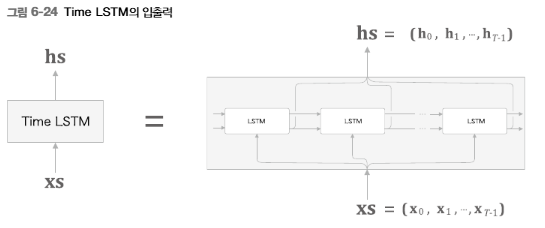   
그런데 앞서 말한 것처럼 RNN에서는 학습할 때 Truncated BPTT를 수행했음   
Truncated BPTT는 역전파의 연결은 적당한 길이로 끊지만, 순전파의 흐름은 그대로 유지함   
그러니 아래 그림처럼 은닉 상태와 기억 셀을 인스턴스 변수로 유지하도록 함   
이렇게 하여 다음번에 forward()가 불렸을 때, 이전 시각의 은닉 상태(와 기억 셀)에서부터 시작할 수 있게 되는 것   
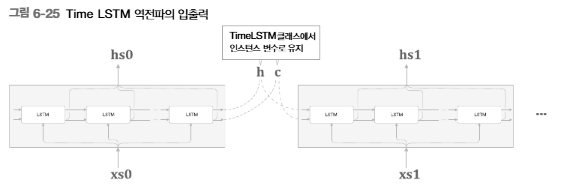   

이전에 Time RNN 계층을 구현한 것과 같이 Time LSTM 계층도 같은 요령으로 구현하면 됨

In [10]:
class TimeLSTM:
    def __init__(self, Wx, Wh, b, stateful=False):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.layers = None

        self.h, self.c = None, None
        self.dh = None
        self.stateful = stateful

    def forward(self, xs):
        Wx, Wh, b = self.params
        N, T, D = xs.shape
        H = Wh.shape[0]

        self.layers = []
        hs = np.empty((N, T, H), dtype='f')

        if not self.stateful or self.h is None:
            self.h = np.zeros((N, H), dtype='f')
        if not self.stateful or self.c is None:
            self.c = np.zeros((N, H), dtype='f')

        for t in range(T):
            layer = LSTM(*self.params)
            self.h, self.c = layer.forward(xs[:, t, :], self.h, self.c)
            hs[:, t, :] = self.h

            self.layers.append(layer)

        return hs

    def backward(self, dhs):
        Wx, Wh, b = self.params
        N, T, H = dhs.shape
        D = Wx.shape[0]

        dxs = np.empty((N, T, D), dtype='f')
        dh, dc = 0, 0

        grads = [0, 0, 0]
        for t in reversed(range(T)):
            layer = self.layers[t]
            dx, dh, dc = layer.backward(dhs[:, t, :] + dh, dc)
            dxs[:, t, :] = dx
            for i, grad in enumerate(layer.grads):
                grads[i] += grad

        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
        self.dh = dh
        return dxs

    def set_state(self, h, c=None):
        self.h, self.c = h, c

    def reset_state(self):
        self.h, self.c = None, None

- LSTM은 은닉 상태 h와 함께 기억 셀 c도 이용하지만, TimeLSTM 클래스의 구현은 TimeRNN 클래스와 흡사함
- 여기에서도 인수 stateful로 상태를 유지할지를 지정   

다음 순서는 이 TimeLSTM을 이용해서 언어 모델을 만들어봄

## LSTM을 사용한 언어 모델

Time LSTM 계층까지 다 구현했으니, 본래 주제인 '언어 모델'을 구현할 차례   
여기서 구현하는 언어 모델은 앞 장에서 구현한 언어 모델과 거의 같음   
아래 그림에서 보듯, 앞 장에서는 Time RNN 계층이 차지하던 부분이 Time LSTM 계층으로 바뀌었는데, 이것이 유일한 차이   
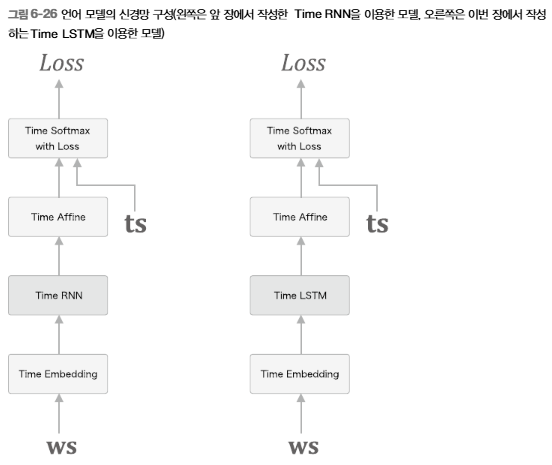   
- 앞 장에서 구현한 언어 모델과의 차이는 LSTM을 사용한다는 점뿐
- 그림의 오른쪽 신경망을 Rnnlm이라는 클래스로 구현할 것
- Rnnlm 클래스는 앞 장에서 설명한 SimpleRnnlm 클래스와 거의 같고, 새로운 메서드를 몇 개 더 제공   

LSTM 계층을 사용하는 Rnnlm 클래스를 구현해보면

In [11]:
import sys
sys.path.append('..')
from common.time_layers import *
import pickle


class Rnnlm():
    def __init__(self, vocab_size=10000, wordvec_size=100, hidden_size=100):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        # 가중치 초기화
        embed_W = (rn(V, D) / 100).astype('f')
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H).astype('f')
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        # 계층 생성
        self.layers = [
            TimeEmbedding(embed_W),
            TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.lstm_layer = self.layers[1]

        # 모든 가중치와 기울기를 리스트에 모음
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, xs):
        for layer in self.layers:
            xs = layer.forward(xs)
        return xs

    def forward(self, xs, ts):
        score = self.predict(xs)
        loss = self.loss_layer.forward(score, ts)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        self.lstm_layer.reset_state()

    def save_params(self, file_name='Rnnlm.pkl'):
        with open(file_name, 'wb') as f:
            pickle.dump(self.params, f)

    def load_params(self, file_name='Rnnlm.pkl'):
        with open(file_name, 'rb') as f:
            self.params = pickle.load(f)

- Rnnlm 클래스에는 Softmax 계층 직전까지를 처리하는 predict() 메서드가 추가되었음
- 이 메서드는 7장에서 수행하는 문장 생성에 사용됨
- 그리고 매개변수 읽기/쓰기를 처리하는 load_params()와 save_params() 메서드도 추가되었음
- 나머지는 앞 장의 SimpleRnnlm 클래스와 같음   

> common/base_model.py에는 BaseModel 클래스가 따로 있음   
> 이 클래스에는 save_params()와 load_params() 메서드가 구현되어 있어서, BaseModel 클래스를 상속하는 것만으로 매개변수를 읽고 쓰는 기능을 얻을 수 있음   
> 나아가 BaseModel은 GPU 대응이나 비트 감소 (16비트의 부동소수점 수로 저장) 같은 최적화도 수행하고 있음   

In [1]:
import sys
sys.path.append('..')
from common.time_layers import *
from common.base_model import BaseModel


class Rnnlm(BaseModel):
    def __init__(self, vocab_size=10000, wordvec_size=100, hidden_size=100):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        # 가중치 초기화
        embed_W = (rn(V, D) / 100).astype('f')
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H).astype('f')
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        # 계층 생성
        self.layers = [
            TimeEmbedding(embed_W),
            TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.lstm_layer = self.layers[1]

        # 모든 가중치와 기울기를 리스트에 모음
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, xs):
        for layer in self.layers:
            xs = layer.forward(xs)
        return xs

    def forward(self, xs, ts):
        score = self.predict(xs)
        loss = self.loss_layer.forward(score, ts)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        self.lstm_layer.reset_state()

이제 이 신경망을 사용해 PTB 데이터셋을 학습해보기   
이번에는 PTB 데이터셋의 훈련 데이터 전부를 사용하여 학습함(앞 장에서는 PTB 데이터셋의 일부만 이용했음)

| 에폭 1 |  반복 1 / 1327 | 시간 0[s] | 퍼플렉서티 10003.85
| 에폭 1 |  반복 21 / 1327 | 시간 2[s] | 퍼플렉서티 2737.15
| 에폭 1 |  반복 41 / 1327 | 시간 5[s] | 퍼플렉서티 1197.01
| 에폭 1 |  반복 61 / 1327 | 시간 7[s] | 퍼플렉서티 947.22
| 에폭 1 |  반복 81 / 1327 | 시간 9[s] | 퍼플렉서티 750.40
| 에폭 1 |  반복 101 / 1327 | 시간 12[s] | 퍼플렉서티 659.44
| 에폭 1 |  반복 121 / 1327 | 시간 14[s] | 퍼플렉서티 626.64
| 에폭 1 |  반복 141 / 1327 | 시간 16[s] | 퍼플렉서티 581.58
| 에폭 1 |  반복 161 / 1327 | 시간 19[s] | 퍼플렉서티 556.30
| 에폭 1 |  반복 181 / 1327 | 시간 21[s] | 퍼플렉서티 575.77
| 에폭 1 |  반복 201 / 1327 | 시간 23[s] | 퍼플렉서티 492.18
| 에폭 1 |  반복 221 / 1327 | 시간 26[s] | 퍼플렉서티 483.98
| 에폭 1 |  반복 241 / 1327 | 시간 28[s] | 퍼플렉서티 441.97
| 에폭 1 |  반복 261 / 1327 | 시간 31[s] | 퍼플렉서티 458.81
| 에폭 1 |  반복 281 / 1327 | 시간 34[s] | 퍼플렉서티 448.92
| 에폭 1 |  반복 301 / 1327 | 시간 36[s] | 퍼플렉서티 387.65
| 에폭 1 |  반복 321 / 1327 | 시간 38[s] | 퍼플렉서티 337.92
| 에폭 1 |  반복 341 / 1327 | 시간 41[s] | 퍼플렉서티 399.18
| 에폭 1 |  반복 361 / 1327 | 시간 43[s] | 퍼플렉서티 402.99
| 에폭 1 |  반복 381 / 1327 | 시간 45[s] | 퍼플렉서티 332.66
| 에폭 1 

c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54140 (\N{HANGUL SYLLABLE PEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47113 (\N{HANGUL 

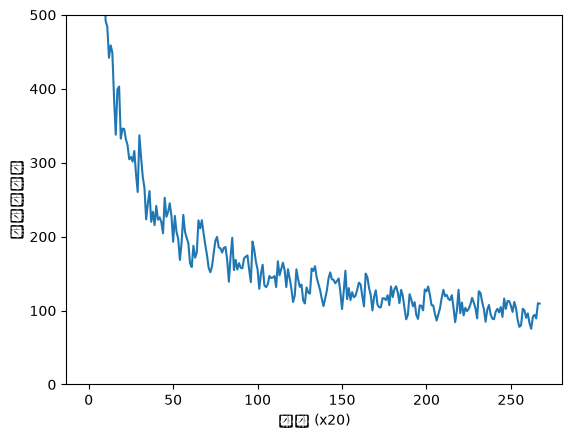

퍼플렉서티 평가 중 ...
234 / 235
테스트 퍼플렉서티:  135.01740356290338


In [2]:
import sys
sys.path.append('..')
from common.optimizer import SGD
from common.trainer import RnnlmTrainer
from common.util import eval_perplexity
from dataset import ptb


# 하이퍼파라미터 설정
batch_size = 20
wordvec_size = 100
hidden_size = 100  # RNN의 은닉 상태 벡터의 원소 수
time_size = 35     # RNN을 펼치는 크기
lr = 20.0
max_epoch = 4
max_grad = 0.25

# 학습 데이터 읽기
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus_test, _, _ = ptb.load_data('test')
vocab_size = len(word_to_id)
xs = corpus[:-1]
ts = corpus[1:]

# 모델 생성
model = Rnnlm(vocab_size, wordvec_size, hidden_size)
optimizer = SGD(lr)
trainer = RnnlmTrainer(model, optimizer)

# 1. 기울기 클리핑을 적용하여 학습
trainer.fit(xs, ts, max_epoch, batch_size, time_size, max_grad,
            eval_interval=20)
trainer.plot(ylim=(0, 500))

# 2. 테스트 데이터로 평가
model.reset_state()
ppl_test = eval_perplexity(model, corpus_test)
print('테스트 퍼플렉서티: ', ppl_test)

# 3. 매개변수 저장
model.save_params()

- 이 코드는 앞 장의 코드(ch05/train.py)와 상당 부분이 같음
- 그러니 앞 장과의 차이를 중심으로 살펴봄
- 우선 1.에서 RnnlmTrainer 클래스를 사용해 모델을 학습시킴
    - RnnlmTrainer 클래스의 fit() 메서드는 모델의 기울기를 구해 모델의 매개변수를 갱신함
    - 이때 인수로 max_grad를 지정해 기울기 클리핑을 적용
    - 참고로 fit() 메서드 내부는 다음처럼 구현되어 있음(실제 코드가 아닌 의사 코드)   
    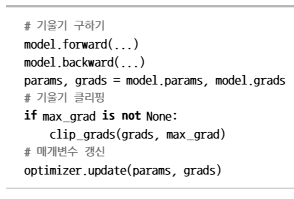   
    - 기울기 클리핑을 수행하는 clip_grads(grads, max_grad) 메서드는 '기울기 폭발 대책' 절에서 구현했음
    - 여기에서는 그 메서드를 이용해 기울기 클리핑을 수행
- 또, 1.의 fit() 메서드에서 인수 eval_interval=20은 20번째 반복마다 퍼플렉서티를 평가하라는 뜻
    - 이번에는 데이터가 크기 때문에 모든 에폭에서 평가하지 않고, 20번 반복될 때마다 평가하도록 했음
    - 그리고 나중에 plot() 메서드를 호출해 그 결과를 그래프로 그림
- 2.에서는 학습이 끝난 후 테스트 데이터를 사용해 퍼플렉서티를 평가함
    - 이때 모델 상태(LSTM의 은닉 상태와 기억 셀)를 재설정하여 평가를 수행하는 점에 주의
    - 참고로, 여기서 퍼플렉서티 평가에 이용한 eval_perplexity() 메서드 함수는 common/util.py에 구현되어 있음(코드를 보면 구현이 매우 단순함을 확인할 수 있음)
- 마지막으로 3.에서 학습이 완료된 매개변수들을 파일로 저장함
    - 다음 장에서 학습된 가중치 매개변수를 사용해 문장을 생성할 때 이 파일을 사용할 것   

이상이 RNNLM의 학습 코드   
코드를 실행해보면 터미널에 다음 결과가 출력됨   
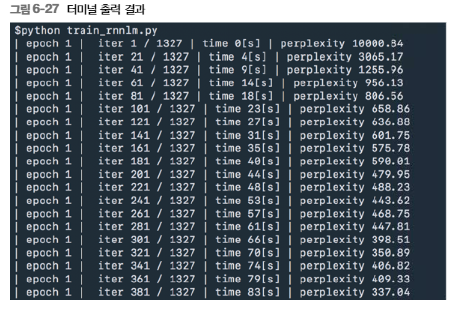   
- 그림에서는 매 20번째 반복의 퍼플렉서티 값이 출력되었음
- 그림에서 첫 번째 퍼플렉서티의 값이 10000.84인데, 이는 (직관적으로는) 다음에 나올 수 있는 후보 단어 수를 10,000개 정도로 좁혔다는 뜻
- 이번 데이터셋의 어휘 수가 10,000개이므로 아직 아무것도 학습하지 않은 상태라는 것
- 그래서 예측을 대충 수행하게 됨
- 하지만 학습을 계속하면서 기대한 대로 퍼플렉서티가 좋아지고 있음
- 실제로 반복이 300회를 넘자 퍼플렉서티가 400을 밑돌기 시작함   

퍼플렉서티의 추이를 그래프로 살펴보면   
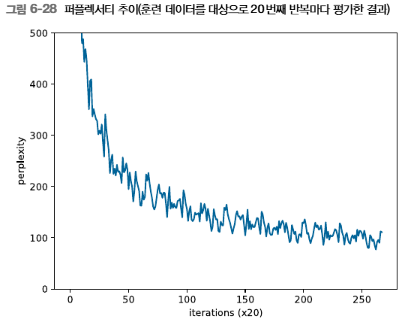   
- 이번 실험에서는 총 4에폭(반복으로 환산하면 1327 * 4회)의 학습을 수행했음
- 그림에서 보듯, 퍼플렉서티가 순조롭게 낮아져서 최종적으로는 100 정도가 되었음
- 그리고 테스트 데이터로 수행한 최종 평가(소스 코드의 2.부분)는 약 136.07
- 이 결과는 실행할 때마다 달라지지만 대략 136 전후가 될 것
- 즉, 우리 모델은 다음에 나올 단어의 후보를 (총 10,000개 중에서) 136개 정도로 줄일 때까지 개선된 것   

그러면 136이라는 값은 실제로 얼마나 좋은 것인지   
사실 그다지 좋은 결과는 아님   
2017년 기준 최첨단 연구에서는 PTB 데이터셋의 퍼플렉서티가 60을 밑돌고 있음   
우리 모델은 아직 개선할 여지가 많다는 방증   
그래서 다음 절에서는 현재의 RNNLM을 한층 더 개선할 계획

## RNNLM 추가 개선

이번 절에서는 현재의 RNNLM의 개선 포인트 3가지를 설명   
그리고 그 개선들을 구현하고, 마지막에는 실제로 얼마나 좋아졌는지를 평가함

### LSTM 계층 다층화

RNNLM으로 정확한 모델을 만들고자 한다면 많은 경우 LSTM 계층을 깊게 쌓아(계층을 여러 겹 쌓아) 효과를 볼 수 있음   
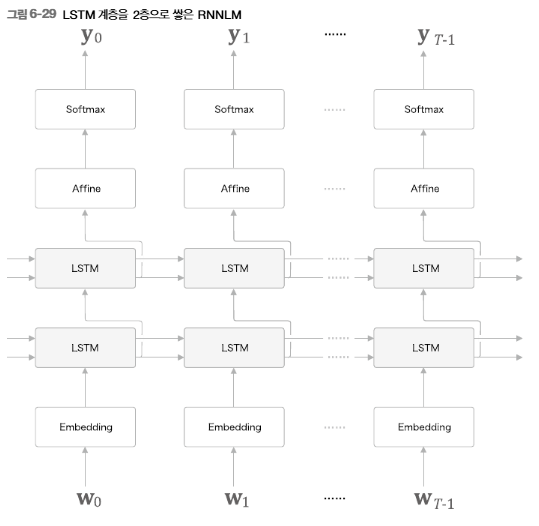   
- 지금까지는 LSTM 계층을 1층만 사용했지만 이를 2층, 3층 식으로 여러 겹 쌓으면 언어 모델의 정확도가 향상되리라 기대할 수 있음
- 예컨대 LSTM을 2층으로 쌓아 RNNLM을 만든다고 하면 위 그림처럼 됨
- 그림은 LSTM 계층을 두 개 쌓은 모습
- 이때 첫 번째 LSTM 계층의 은닉 상태가 두 번째 LSTM 계층에 입력됨
- 이와 같은 요령으로 LSTM 계층을 몇 층이라도 쌓을 수 있으며, 그 결과 더 복잡한 패턴을 학습할 수 있게 됨
- 피드포워드 신경망에서 계층을 쌓는 이야기와 같음
- 책 1권에서는 Affine 계층이나 합성곱 계층 등을 더 깊게 쌓을수록 모델의 표현력이 좋아짐을 확인했음

그렇다면 몇 층이나 쌓아야 하는지?   
물론 그건 하이퍼파라미터에 관한 문제   
쌓는 층 수는 하이퍼파라미터이므로 처리할 문제의 복잡도나 준비된 학습 데이터의 양에 따라 적절하게 결정해야 함   
참고로, PTB 데이터셋의 언어 모델에서는 LSTM의 층 수는 2 ~ 4 정도일 때 좋은 결과를 얻는 것 같다고 판단됨   

> 구글 번역에서 사용하는 GNMT 모델은 LSTM을 8층이나 쌓은 신경망이라고 함   
> 이 예가 증명하듯, 처리할 문제가 복잡하고 학습 데이터를 대량으로 준비할 수 있다면 LSTM 계층을 '깊게' 쌓는 것이 정확도 향상을 이끌 수도 있음

### 드롭아웃에 의한 과적합 억제

LSTM 계층을 다층화하면 시계열 데이터의 복잡한 의존 관계를 학습할 수 있을 것이라 기대할 수 있음   
다르게 표현하자면, 층을 깊게 쌓음으로써 표현력이 풍부한 모델을 만들 수 있음   
그러나 이런 모델은 종종 **과적합(overfitting)(과대적합)** 을 일으킴   
더 나쁜 것은, RNN은 일반적인 피드포워드 신경망보다 쉽게 과적합을 일으킨다는 것   
따라서 RNN의 과적합 대책은 중요하고, 활발하게 연구되는 주제   

> 과적합이란 훈련 데이터에만 너무 치중해 학습된 상태   
> 즉, 일반화 능력이 결여된 상태   
> 우리가 바라는 것은 일반화 능력이 높은 모델   
> 이런 모델을 얻으려면 훈련 데이터로 수행한 평가와 검증 데이터로 한 평가를 비교하여, 과적합이 일어나지 않았는지를 판단해가며 모델을 설계해야 함   

과적합을 억제하는 전통적인 방법이 있음   
'훈련 데이터의 양 늘리기'와 '모델의 복잡도 줄이기'가 있음   
그 외에는 모델의 복잡도에 페널티를 주는 **정규화(normalization)** 도 효과적   
예컨대 L2 정규화는 가중치가 너무 커지면 페널티를 부과함   

또, 드롭아웃(dropout)처럼 훈련 시 계층 내의 뉴런 몇 개(예컨대 50% 등)를 무작위로 무시하고 학습하는 방법도 일종의 정규화라고 할 수 있음   
이번 절에서는 이 드롭아웃에 관해 자세히 살펴보고 RNN에 적용해봄   
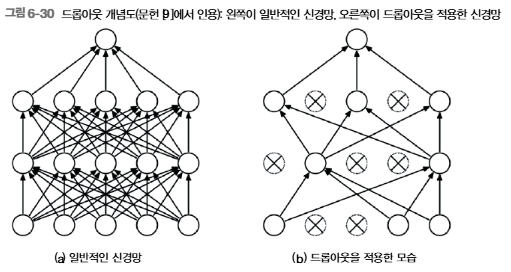   
- 그림과 같이 드롭아웃은 무작위로 뉴런을 선택하여 선택한 뉴런을 무시함
- 무시한다는 말은 그 앞 계층으로부터의 신호 전달을 막는다는 뜻
- 이 '무작위한 무시'가 제약이 되어 신경망의 일반화 성능을 개선하는 것
- 책 1권에서는 드롭아웃 계층을 구현해봤는데, 아래 그림처럼 드롭아웃 계층을 활성화 함수 뒤에 삽입하는 방법으로 과적합 억제에 기여하는 것을 확인했음   

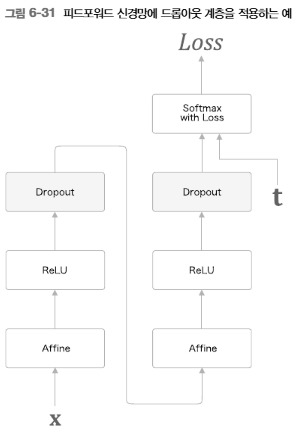   
그럼 RNN을 사용한 모델에서는 드롭아웃 계층을 어디에 삽입해야 하는지   

첫 번째 후보는 아래 그림과 같이 LSTM 계층의 시계열 방향으로 삽입하는 것   
하지만 정답을 먼저 말하자면, 이는 좋은 방법이 아님   
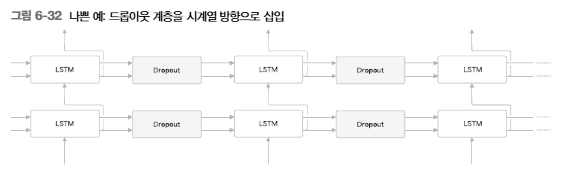   
RNN에서 시계열 방향으로 드롭아웃을 넣어버리면 (학습 시) 시간이 흐름에 따라 정보가 사라질 수 있음   
즉, 흐르는 시간에 비례해 드롭아웃에 의한 노이즈가 축적됨   
노이즈 축적을 고려하면, 시간축 방향으로의 드롭아웃은 그만두는 편이 좋을 것   

그렇다면 아래 그림처럼 드롭아웃 계층을 깊이 방향(상하 방향)으로 삽입하는 방안을 생각해볼 수 있음   
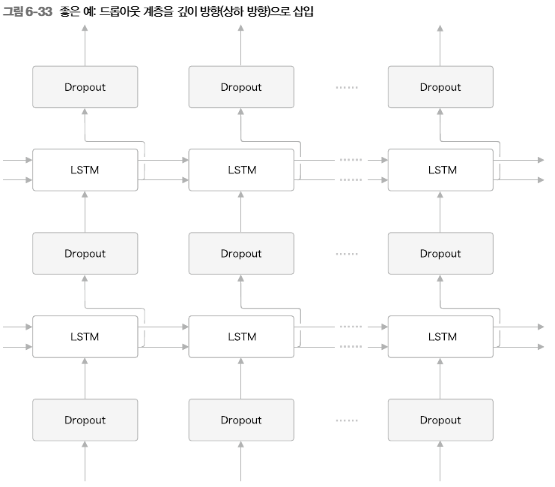   
이렇게 구성하면 시간 방향(좌우 방향)으로 아무리 진행해도 정보를 잃지 않음   
드롭아웃이 시간축과는 독립적으로 깊이 방향(상하 방향)에만 영향을 주는 것   

> [그림 6-31]과 [그림 6-33]을 비교해보면   
> [그림 6-31]은 드롭아웃을 피드포워드 신경망에 적용한 경우인데, 깊이 방향으로 적용한 것을 알 수 있음   
> 이와 같은 방식으로, [그림 6-33]에서도 드롭아웃을 깊이 방향으로만 적용하여 피드포워드 때처럼 과적합을 억제할 수도 있음   

지금까지 이야기한 것처럼, '일반적인 드롭아웃'은 시간 방향에는 적합하지 않음   
그러나 최근 연구에서는 RNN의 시간 방향 정규화를 목표로 하는 방법이 다양하게 제안되고 있음   
예컨대 **변형 드롭아웃(Variational Dropout)** 을 제안했고, 시간 방향으로 적용하는 데 성공한 연구가 있음   

변형 드롭아웃은 깊이 방향은 물론 시간 방향에도 이용할 수 있어서 언어 모델의 정확도를 한층 더 향상시킬 수 있음   
그 구조는 아래 그림과 같은데, 같은 계층에 속한 드롭아웃들은 같은 마스크(mask)를 공유함   
여기서 말하는 '마스크'란 데이터의 '통과/차단'을 결정하는 이진(binary) 형태의 무작위 패턴을 가리킴   
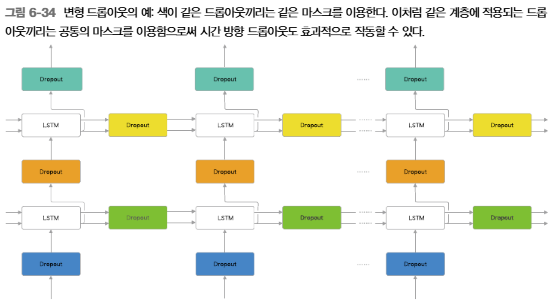   
- 그림에서 보듯 같은 계층의 드롭아웃끼리 마스크를 공유함으로써 마스크가 '고정'됨
- 그 결과 정보를 잃게 되는 방법도 '고정'되므로, 일반적인 드롭아웃 때와 달리 정보가 지수적으로 손실되는 사태를 피할 수 있음   

> 변형 드롭아웃은 일반 드롭아웃보다 결과가 좋다고 함   
> 하지만 이번 장에서는 변형 드롭아웃을 이용하지 않고, 일반적인 드롭아웃을 사용함

### 가중치 공유

언어 모델을 개선하는 아주 간단한 트릭 중 **가중치 공유(weight tying)** 가 있음   
weight tying을 직역하면 '가중치를 연결한다'이지만, 실질적으로는 아래 그림에서 보듯 가중치를 공유하는 효과를 줌   
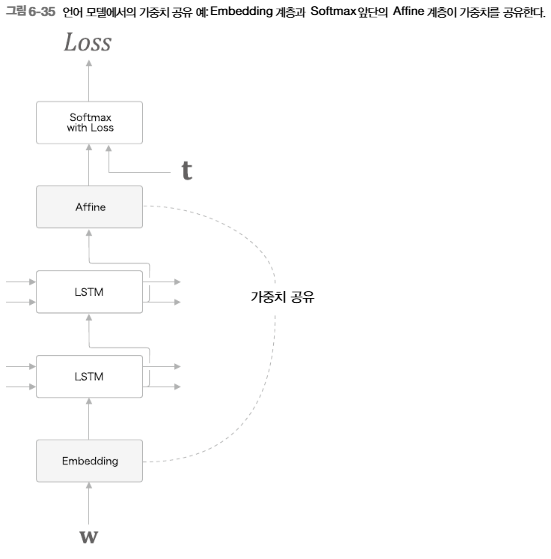   
- 그림처럼 Embedding 계층의 가중치와 Affine 계층의 가중치를 연결하는(공유하는) 기법이 가중치 공유
- 두 계층이 가중치를 공유함으로써 학습하는 매개변수 수가 크게 줄어드는 동시에 정확도도 향상되는 일석이조의 기술   

그럼, 가중치 공유를 구현 관점에서 생각해보면   
어휘 수를 V로, LSTM의 은닉 상태의 차원 수를 H라고 해보면   
Embedding 계층의 가중치는 형상이 V×H이며, Affine 계층의 가중치 형상은 H×V가 됨   
이때 가중치 공유를 적용하려면 Embedding 계층의 가중치를 전치하여 Affine 계층의 가중치로 설정하기만 하면 됨   
그리고 이 아주 간단한 트릭 하나로 훌륭한 결과를 얻을 수 있음   

> 가중치 공유가 효과가 있는 이유는?   
> 직관적으로는 가중치를 공유함으로써 학습해야 할 매개변수 수를 줄일 수 있고, 그 결과 학습하기가 더 쉬워지기 때문이라고 생각할 수 있음   
> 게다가 매개변수 수가 줄어든다 함은 과적합이 억제되는 혜택으로 이어질 수 있음

### 개선된 RNNLM 구현

지금까지 RNNLM의 개선점 3개를 설명했음   
이 기법들의 효과가 얼마나 대단한지 확인해 보기 위해 이번 절에서는 아래 그림의 계층 구성을 BetterRnnlm 클래스로 구현해봄   
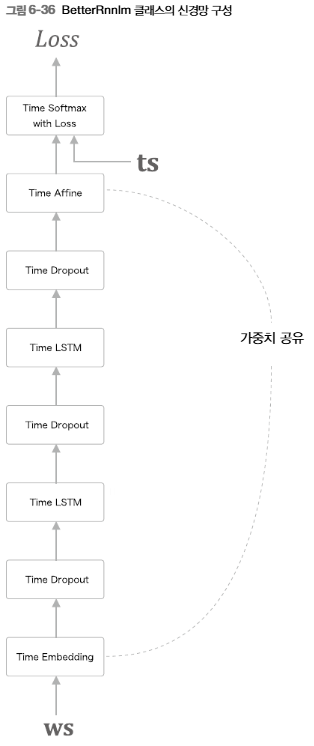   
- 그림에서 보듯, 여기에서의 개선점은 다음 세 가지
    - LSTM 계층의 다층화(여기에서는 2층)
    - 드롭아웃 사용(깊이 방향으로만 적용)
    - 가중치 공유(Embedding 계층과 Affine 계층에서 가중치 공유)

In [2]:
import sys
sys.path.append('..')
from common.time_layers import *
from common.np import *  # import numpy as np
from common.base_model import BaseModel


class BetterRnnlm(BaseModel):
    def __init__(self, vocab_size=10000, wordvec_size=650,
                 hidden_size=650, dropout_ratio=0.5):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        embed_W = (rn(V, D) / 100).astype('f')
        lstm_Wx1 = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh1 = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b1 = np.zeros(4 * H).astype('f')
        lstm_Wx2 = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_Wh2 = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b2 = np.zeros(4 * H).astype('f')
        affine_b = np.zeros(V).astype('f')

        # 세 가지 개선
        self.layers = [
            TimeEmbedding(embed_W),
            TimeDropout(dropout_ratio),
            TimeLSTM(lstm_Wx1, lstm_Wh1, lstm_b1, stateful=True),
            TimeDropout(dropout_ratio),
            TimeLSTM(lstm_Wx2, lstm_Wh2, lstm_b2, stateful=True),
            TimeDropout(dropout_ratio),
            TimeAffine(embed_W.T, affine_b)  # 가중치 공유
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.lstm_layers = [self.layers[2], self.layers[4]]
        self.drop_layers = [self.layers[1], self.layers[3], self.layers[5]]

        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, xs, train_flg=False):
        for layer in self.drop_layers:
            layer.train_flg = train_flg

        for layer in self.layers:
            xs = layer.forward(xs)
        return xs

    def forward(self, xs, ts, train_flg=True):
        score = self.predict(xs, train_flg)
        loss = self.loss_layer.forward(score, ts)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        for layer in self.lstm_layers:
            layer.reset_state()

- 코드에서 앞서 말한 세 가지 개선이 이뤄지고 있음
- 구체적으로는 TimeLSTM 계층을 2개 겹치고, 사이사이에 TimeDropout 계층을 사용함
- 그리고 TimeEmbedding 계층과 TimeAffine 계층에서 가중치를 공유함   

다음은 이 개선된 BetterRnnlm 클래스를 학습시킬 차례   
하지만 그전에 지금부터 수행하는 학습 코드에 한 가지 궁리를 더해볼까 함   
그 궁리란 매 에폭에서 검증 데이터로 퍼플렉서티를 평가하고, 그 값이 나빠졌을 경우에만 학습률을 낮추는 것   
이 기술은 실전에서 자주 쓰이며, 더 좋은 결과로 이어지는 경우가 많음   
참고로, 이 구현은 PyTorch 언어 모델의 구현 예를 참고했음

In [3]:
import sys
sys.path.append('..')
from common import config
# GPU에서 실행하려면 아래 주석을 해제하세요(CuPy 필요).
# ==============================================
config.GPU = True
# ==============================================
from common.optimizer import SGD
from common.trainer import RnnlmTrainer
from common.util import eval_perplexity, to_gpu
from dataset import ptb


# 하이퍼파라미터 설정
batch_size = 20
wordvec_size = 650
hidden_size = 650
time_size = 35
lr = 20.0
max_epoch = 40
max_grad = 0.25
dropout = 0.5

# 학습 데이터 읽기
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus_val, _, _ = ptb.load_data('val')
corpus_test, _, _ = ptb.load_data('test')

if config.GPU:
    corpus = to_gpu(corpus)
    corpus_val = to_gpu(corpus_val)
    corpus_test = to_gpu(corpus_test)

vocab_size = len(word_to_id)
xs = corpus[:-1]
ts = corpus[1:]

model = BetterRnnlm(vocab_size, wordvec_size, hidden_size, dropout)
optimizer = SGD(lr)
trainer = RnnlmTrainer(model, optimizer)

best_ppl = float('inf')
for epoch in range(max_epoch):
    trainer.fit(xs, ts, max_epoch=1, batch_size=batch_size,
                time_size=time_size, max_grad=max_grad)

    model.reset_state()
    ppl = eval_perplexity(model, corpus_val)
    print('검증 퍼플렉서티: ', ppl)

    if best_ppl > ppl:
        best_ppl = ppl
        model.save_params()
    else:
        lr /= 4.0
        optimizer.lr = lr

    model.reset_state()
    print('-' * 50)


# 테스트 데이터로 평가
model.reset_state()
ppl_test = eval_perplexity(model, corpus_test)
print('테스트 퍼플렉서티: ', ppl_test)

| 에폭 1 |  반복 1 / 1327 | 시간 1[s] | 퍼플렉서티 9999.39
| 에폭 1 |  반복 21 / 1327 | 시간 2[s] | 퍼플렉서티 3598.86
| 에폭 1 |  반복 41 / 1327 | 시간 4[s] | 퍼플렉서티 1882.03
| 에폭 1 |  반복 61 / 1327 | 시간 6[s] | 퍼플렉서티 1290.79
| 에폭 1 |  반복 81 / 1327 | 시간 7[s] | 퍼플렉서티 1127.12
| 에폭 1 |  반복 101 / 1327 | 시간 9[s] | 퍼플렉서티 802.02
| 에폭 1 |  반복 121 / 1327 | 시간 11[s] | 퍼플렉서티 785.95
| 에폭 1 |  반복 141 / 1327 | 시간 12[s] | 퍼플렉서티 723.65
| 에폭 1 |  반복 161 / 1327 | 시간 14[s] | 퍼플렉서티 680.53
| 에폭 1 |  반복 181 / 1327 | 시간 16[s] | 퍼플렉서티 666.73
| 에폭 1 |  반복 201 / 1327 | 시간 18[s] | 퍼플렉서티 587.67
| 에폭 1 |  반복 221 / 1327 | 시간 19[s] | 퍼플렉서티 566.42
| 에폭 1 |  반복 241 / 1327 | 시간 21[s] | 퍼플렉서티 521.22
| 에폭 1 |  반복 261 / 1327 | 시간 23[s] | 퍼플렉서티 537.71
| 에폭 1 |  반복 281 / 1327 | 시간 25[s] | 퍼플렉서티 510.21
| 에폭 1 |  반복 301 / 1327 | 시간 26[s] | 퍼플렉서티 449.57
| 에폭 1 |  반복 321 / 1327 | 시간 28[s] | 퍼플렉서티 394.32
| 에폭 1 |  반복 341 / 1327 | 시간 30[s] | 퍼플렉서티 445.91
| 에폭 1 |  반복 361 / 1327 | 시간 31[s] | 퍼플렉서티 472.38
| 에폭 1 |  반복 381 / 1327 | 시간 33[s] | 퍼플렉서티 377.76
| 에폭 1 

- 앞서 설명한 것처럼 이 코드는 학습을 진행하면서 매 에폭마다 검증 데이터로 퍼플렉서티를 평가하고, 그 값이 기존 퍼플렉서티(best_ppl)보다 낮으면 학습률을 1/4로 줄임
- 이를 위해 이 코드에서는 RnnlmTrainer 클래스의 fit() 메서드를 이용해 1에폭분의 학습을 수행한 다음, 검증 데이터로 퍼플렉서티의 평가하는 처리를 for 문에서 반복함   

이제 이 학습용 코드를 실행해보면   

> 이 학습에는 상당한 시간이 소요됨   
> CPU에서 실행하면 2일 정도가 걸리기도 함   
> GPU를 사용해도 5시간 정도 걸릴 수 있음(GPU에서 실행하는 방법은 코드 앞쪽의 주석에서 설명했음)   
> 그래서 책에서는 학습을 마친 가중치를 다음 URL에 준비해뒀음   
> https://www.oreilly.co.jp/pub/9784873118369/BetterRnnlm.pkl   

이 코드를 실행하면 퍼플렉서티가 순조롭게 낮아짐   
그리고 테스트 데이터로 얻은 최종 퍼플렉서티는 75.76 정도가 될 것(실행할 때마다 결과가 달라짐)   
개선 전 RNNLM의 퍼플렉서티가 약 136이었음을 생각하면 상당히 개선됐다고 할 수 있음   
LSTM의 다층화로 표현력을 높이고, 드롭아웃으로 범용성을 향상시켰으며, 가중치 공유로 가중치를 효율적으로 이용함으로써 이런 큰 폭의 정확도 향상을 달성할 수 있었음

### 첨단 연구로

이것으로 우리 RNNLM의 개선은 끝   
우리는 RNNLM에 몇 가지 개선을 더해 상당한 수준의 향상을 이끌어낼 수 있었음   
PTB 데이터셋의 테스트 데이터에서 퍼플렉서티가 75 정도라는 것은 상당히 좋은 결과라고 말할 수 있음   
하지만 첨단 연구들은 더욱 앞서 있음   
이번 절에서는 그런 최신 연구들의 결과만 간략히 소개하려 함   
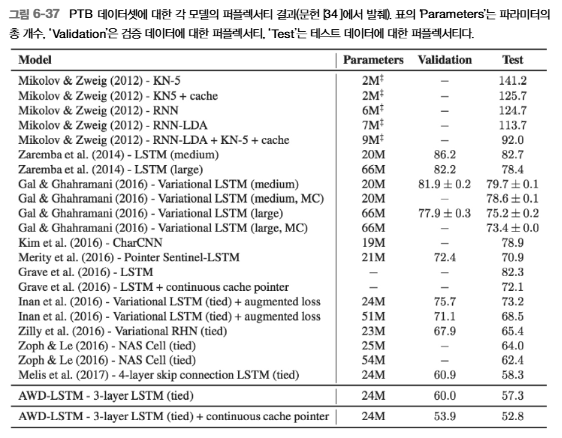   
- 그림에는 역대 최고의 언어 모델들의 PTB 데이터셋에 대한 퍼플렉서티 결과가 표로 정리되어 있음
- 표의 'Test' 열을 보면, 계속해서 새로운 기법이 나타나면서 퍼플렉서티도 점차 내려가는 모습을 확인할 수 있음
- 그리고 마지막 줄에 와서는 52.8까지 내려갔는데, 실제로 이 52.8이라는 숫자는 매우 놀라운 결과
- 몇 년 전만 해도 PTB 데이터셋의 퍼플렉서티가 50에 근접하는 것은 생각할 수도 없었음   

여기에서는 최첨단 연구의 결과만을 보여준 것   
우리 모델과는 간극이 좀 큼   
하지만 중요한 것은 그림의 첨단 모델과 우리 모델에는 공통점이 많다는 사실   
예컨대 첨단 모델에서도 다층 LSTM을 사용함   
그리고 드롭아웃 기반의 정규화를 수행하고(실제로는 변형 드롭아웃과 DropConnect) 가중치 공유도 수행함   
여기에 더해, 한층 더 세련된 최적화나 정규화 기법들이 적용되고, 또 하이퍼파라미터 튜닝도 매우 정밀하게 하고 있음   
그 결과 52.8이라는 경이적인 수치를 달성했음   

> 그림의 마지막 모델의 이름은 "AWD-LSTM 3-layer LSTM(tied) + continuous cache pointer"   
> 여기서 "continuous cache pointer"는 8장에서 자세하게 배우는 어텐션을 기반으로 한 기술   
> 어텐션은 매우 중요한 기술이며 다양한 용도로 쓰임   
> 언어 모델이라는 작업에서도 정확도 향상에 크게 공헌하고 있음

## 정리

이번 장에서는 게이트가 추가된 RNN을 살펴봤음   
앞 장의 단순한 RNN에서는 기울기 소실(또는 기울기 폭발)이 문제가 되었는데,   
그것을 대신하는 계층으로써 게이트가 추가된 RNN(구체적으로는 LSTM과 GRU 등)이 효과가 있음을 설명했음   
이 계층들에는 게이트라는 구조가 사용되며, 게이트는 데이터와 기울기 흐름을 적절히 제어하는 메커니즘   

또한, LSTM 계층을 사용한 언어 모델을 만들어봤음   
그리고 PTB 데이터셋을 학습하여 퍼플렉서티를 구했음   
나아가 LSTM 다층화, 드롭아웃, 가중치 공유 등의 기법을 적용해 정확도를 큰 폭으로 향상시켰음   
이 기법들은 2017년 기준 최첨단 연구에서도 실제로 사용되고 있음   

다음 장에서는 언어 모델을 사용해 문장을 생성해볼 것   
그리고 기계 번역처럼 한 언어(출발어)를 다른 언어(도착어)로 변환하는 모델을 자세히 살펴볼 것

### 이번 장에서 배운 내용

- 단순한 RNN의 학습에서는 기울기 소실과 기울기 폭발이 문제가 됨
- 기울기 폭발에는 기울기 클리핑, 기울기 소실에는 게이트가 추가된 RNN(LSTM과 GRU 등)이 효과적
- LSTM에는 input 게이트, forget 게이트, output 게이트 등 3개의 게이트가 있음
- 게이트에는 전용 가중치가 있으며, 시그모이드 함수를 사용하여 0.0 ~ 1.0 사이의 실수를 출력함
- 언어 모델 개선에는 LSTM 계층 다층화, 드롭아웃, 가중치 공유 등의 기법이 효과적
- RNN의 정규화는 중요한 주제이며, 드롭아웃 기반의 다양한 기법이 제안되고 있음